# Granite 

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from granite.features import Features
from granite.decompositions import get_components_brute_force, get_regional_decompositions

In [3]:
def generate_problem(N, seed, rho):
    # Generate input
    np.random.seed(seed)
    X_1 = np.random.normal(0, 1, size=(N,))
    cov = ( 1 - rho ) * np.eye(2) + rho * np.ones(2)
    X_2_3 = np.random.multivariate_normal(mean=[0, 0], cov=cov, size=(N,))
    X_4 = np.random.normal(0, 1, size=(N,))

    # Model to explain
    def f(X):
        return X[:, 0] * X[:, 1] + X[:, 2] * X[:, 3]
    return np.column_stack((X_1, X_2_3, X_4)), f

# We generate the data and models. The data X is stored in a (N, d) numpy array
X, f = generate_problem(2000, 42, rho=0.75)
features = Features(
                X, 
                names=[f"x{i}" for i in range(1, 5)], 
                types=["num", "num", "num", "num"]
            )
n_features = len(features)
features.summary()

|Idx|        Name        |        Type        |    Card    |      Groups      |
-------------------------------------------------------------------------------
| 0 | x1                 | num                | inf        | [0]              |
| 1 | x2                 | num                | inf        | [1]              |
| 2 | x3                 | num                | inf        | [2]              |
| 3 | x4                 | num                | inf        | [3]              |
-------------------------------------------------------------------------------



In [4]:
# Compute the Anchored Decomposition. Averaging it column-wise leads to the marginal decomposition.
decomposition = get_components_brute_force(f, X, X, features, anchored=True)
display(decomposition.keys())
display(decomposition[()].shape) # The null set is the model evaluation h(x^(i)) at all datapoints
display(decomposition[(0,)].shape)  # The component (0,) is a NxN matric whose ij term is h_{0,x^(j)}(x^(i))

dict_keys([(), (0,), (1,), (2,), (3,)])

(2000,)

(2000, 2000)

## Pure and Full Sobol effects


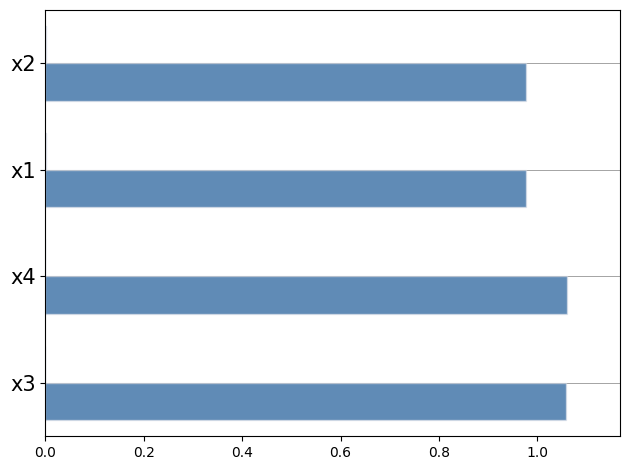

In [5]:
from granite.plots import bar
from granite.experiments import get_closed_total_sobol

H_tensor = np.stack([decomposition[(i,)] for i in range(n_features)], axis=-1)
closed_sobol, total_sobol = get_closed_total_sobol(H_tensor)
bar([closed_sobol, total_sobol], features.names())

This plot shows the pure and total sobol effects. The pure effect is null for all features so there are strong disagreements.

In [6]:
from granite.fd_trees import FDTree
from granite.experiments import get_marginal_pure_vs_full_variance_loss_fn

marginal_pure_vs_full_loss_fn = get_marginal_pure_vs_full_variance_loss_fn(
                                        decomposition=decomposition,
                                        U=[(i,) for i in range(n_features)]
                                )

tree = FDTree(features, max_depth=2, save_losses=True, branching_per_node=3)
tree.fit(X, loss_fn=marginal_pure_vs_full_loss_fn)
tree.print(verbose=True)


Loss 1.0000
Samples 2000
If x2 ≤ -0.0143:
|   Loss 0.2449
|   Samples 950
|   If x3 ≤ -0.3943:
|   |   Loss 0.1307
|   |   Samples 570
|   |   Region 0
|   else:
|   |   Loss 0.0210
|   |   Samples 380
|   |   Region 1
else:
|   Loss 0.3097
|   Samples 1050
|   If x3 ≤ 0.3855:
|   |   Loss 0.0328
|   |   Samples 420
|   |   Region 2
|   else:
|   |   Loss 0.1192
|   |   Samples 630
|   |   Region 3
Final Loss 0.3037


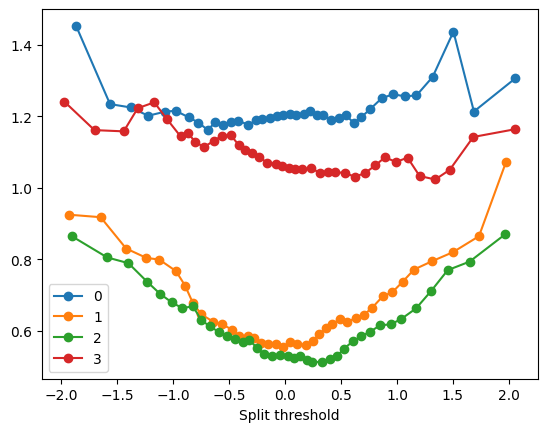

In [9]:
# Plot the loss function as a function of split candidate
plt.figure()
for i in range(n_features):
    splits = tree.root.splits[i]
    objectives = tree.root.objectives[i]
    plt.plot(splits, objectives, '-o', label=i)
plt.xlabel("Split threshold")
plt.legend()

In [10]:
# Use the tree to compute regional decompositions
regions = tree.predict(X)
print(regions[:10])
n_regions = tree.n_regions
rules = tree.rules()
print(rules)
regional_decompositions = get_regional_decompositions(decomposition, regions, regions, n_regions)

[3 3 3 2 1 3 3 0 2 0]
{0: '(x2<=-0.01 & x3<=-0.39)', 1: '(x2<=-0.01 & x3>-0.39)', 2: '(x2>-0.01 & x3<=0.39)', 3: '(x2>-0.01 & x3>0.39)'}


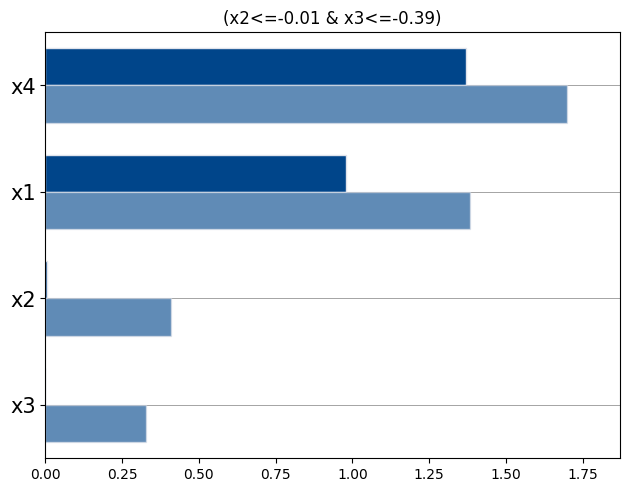

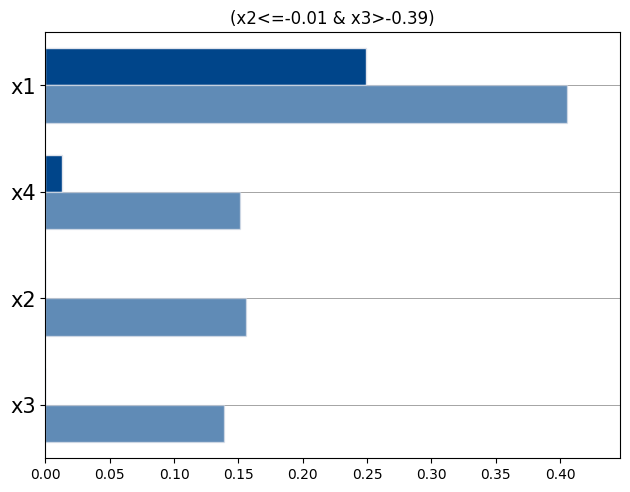

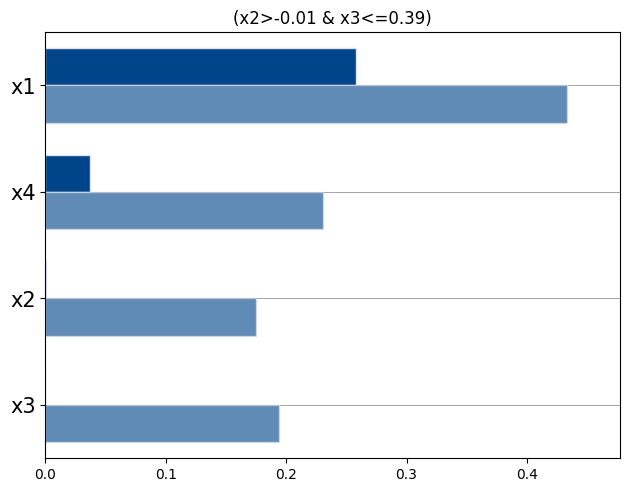

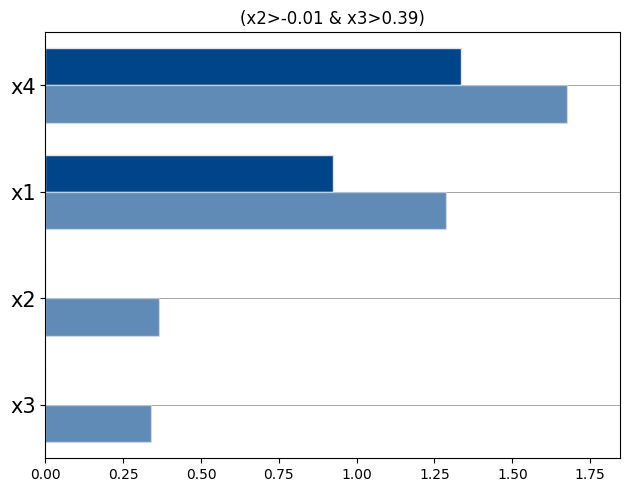

In [11]:
for r in range(tree.n_regions):
    H_tensor = np.stack([regional_decompositions[r][(i,)] for i in range(n_features)], axis=-1)
    closed_sobol, total_sobol = get_closed_total_sobol(H_tensor)
    bar([closed_sobol, total_sobol], features.names())
    plt.title(rules[r])

## Marginal-vs-Conditional Sobol Effect

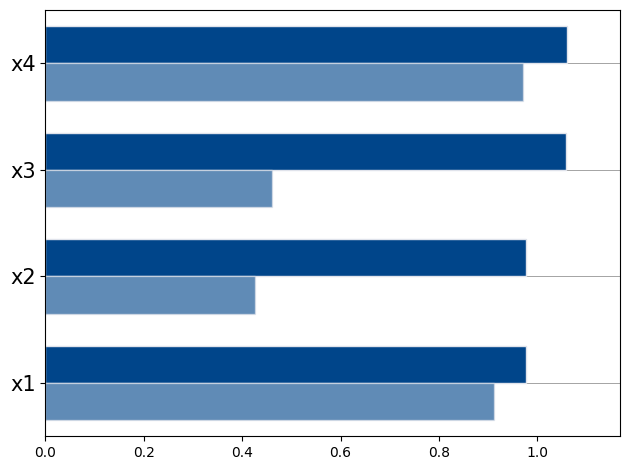

In [13]:
from sklearn.tree import DecisionTreeRegressor
from granite.experiments import get_marginal_conditional_sobol
from granite.utils import create_bins_for_data_partition_tree, decomposition_to_R

bins, binned_features = create_bins_for_data_partition_tree(
    X, cat_feature_indices=[], max_leaf_nodes=10
)
R = decomposition_to_R(decomposition)
marginal_sobol = np.zeros(n_features)
cond_sobol = np.zeros(n_features)
for i in range(n_features):
    marginal_sobol[i], cond_sobol[i] = get_marginal_conditional_sobol(binned_features[i], R[(i,)])

bar([marginal_sobol, cond_sobol], features.names())


In [ ]:
from granite.experiments import get_marginal_vs_condition_full_variance_loss_fn

marginal_pure_vs_full_loss_fn = get_marginal_vs_condition_full_variance_loss_fn(
                                        decomposition=decomposition,
                                        U=[(i,) for i in range(n_features)],
                                        binned_features=binned_features
                                )

tree = FDTree(features, max_depth=2, save_losses=True, branching_per_node=1)
tree.fit(X, loss_fn=marginal_pure_vs_full_loss_fn)
tree.print(verbose=True)

Loss 1.0000
Samples 2000
If x2 ≤ -0.0143:
|   Loss 0.0880
|   Samples 950
|   Region 0
else:
|   Loss 0.1257
|   Samples 1050
|   If x3 ≤ 0.4824:
|   |   Loss 0.0082
|   |   Samples 473
|   |   Region 1
|   else:
|   |   Loss 0.0632
|   |   Samples 577
|   |   Region 2
Final Loss 0.1594


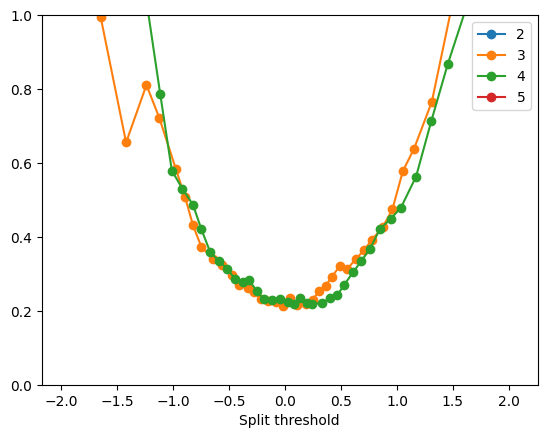

In [ ]:
plt.figure()
for i in range(n_features):
    splits = tree.root.splits[i]
    objectives = tree.root.objectives[i]
    plt.plot(splits, objectives, '-o', label=i+2)
plt.xlabel("Split threshold")
plt.ylim(0, 1)
plt.legend()

In [17]:
regions = tree.predict(X)
print(regions[:10])
n_regions = tree.n_regions
rules = tree.rules()
print(rules)
regional_R = get_regional_decompositions(R, regions, regions, n_regions)
regional_binned_features = [[]] * n_regions
for r in range(n_regions):
    regional_binned_features[r] = [[]] * n_features
    in_region = regions == r
    for i in range(n_features):
        regional_binned_features[r][i] = binned_features[i][in_region]

[2 2 2 1 0 2 1 0 1 0]
{0: 'x2<=-0.01', 1: '(x2>-0.01 & x3<=0.48)', 2: '(x2>-0.01 & x3>0.48)'}


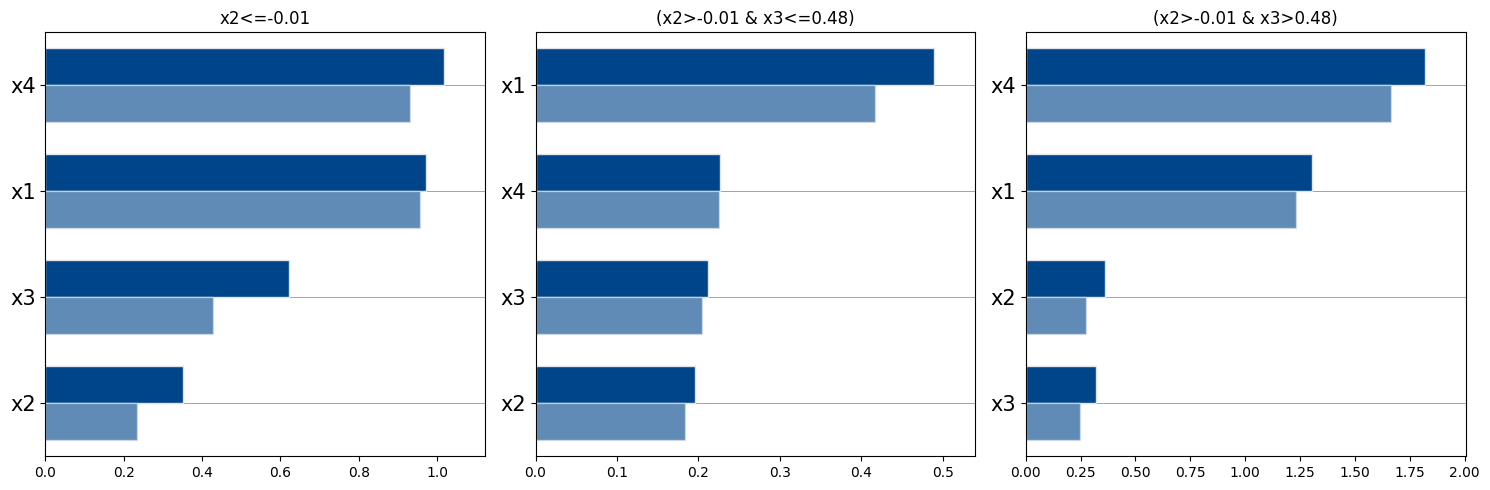

In [18]:
fig, axes = plt.subplots(1, n_regions, figsize=(5*n_regions, 5))
for r in range(tree.n_regions):
    marginal_sobol, cond_sobol = np.zeros(n_features), np.zeros(n_features)
    for i in range(n_features):
        marginal_sobol[i], cond_sobol[i] = get_marginal_conditional_sobol(regional_binned_features[r][i], regional_R[r][(i,)])
    bar([marginal_sobol, cond_sobol], features.names(), ax=axes[r])
    axes[r].set_title(rules[r])